# Profitable App Profiles for the App Store and Google Play Markets

In [45]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from csv import reader

In [6]:
# Importing datasets

# The Google Play dataset #
opened_file = open('../data/googleplaystore.csv', encoding='utf-8')
read_file = reader(opened_file)
android = list(read_file)
android_header = android[0]
android = android[1:]

# The Apple Store dataset #
opened_file = open('../data/AppleStore.csv', encoding='utf-8')
read_file = reader(opened_file)
ios = list(read_file)
ios_header = ios[0]
ios = ios[1:]

In [7]:
# Columns in google play dataset
print(android_header)

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [8]:
# Columns in apple store dataset
print(ios_header)

['id', 'track_name', 'size_bytes', 'currency', 'price', 'rating_count_tot', 'rating_count_ver', 'user_rating', 'user_rating_ver', 'ver', 'cont_rating', 'prime_genre', 'sup_devices.num', 'ipadSc_urls.num', 'lang.num', 'vpp_lic']


To make it easier to explore the two data sets, we'll first write a function named explore_data() that we can use repeatedly to explore rows in a more readable way. We'll also add an option for our function to show the number of rows and columns for any data set.

In [9]:
# A function to explore more about the datasets
def explore_data(dataset, start, end, rows_and_columns=False):
    dataset_slice = dataset[start:end]
    for row in dataset_slice:
        print(row)
        print("\n") # add a new line between rows

    if rows_and_columns:
        print('Number of rows:', len(dataset))
        print('Number of columns:', len(dataset[0]))

explore_data(android, 0, 3, True)
    

['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', '7-Jan-18', '1.0.0', '4.0.3 and up']


['Coloring book moana', 'ART_AND_DESIGN', '3.9', '967', '14M', '500,000+', 'Free', '0', 'Everyone', 'Art & Design;Pretend Play', '15-Jan-18', '2.0.0', '4.0.3 and up']


['U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'ART_AND_DESIGN', '4.7', '87510', '8.7M', '5,000,000+', 'Free', '0', 'Everyone', 'Art & Design', '1-Aug-18', '1.2.4', '4.0.3 and up']


Number of rows: 10841
Number of columns: 13


We can see that the Google Play Store has 10841 apps and 13 columns. Columns which will be useful for analysis are 'App', 'Category', 'Reviews', 'Installs', 'Type', 'Price', 'Genres'.

In [10]:
explore_data(ios, 0, 3, True)

['284882215', 'Facebook', '389879808', 'USD', '0', '2974676', '212', '3.5', '3.5', '95', '4+', 'Social Networking', '37', '1', '29', '1']


['389801252', 'Instagram', '113954816', 'USD', '0', '2161558', '1289', '4.5', '4', '10.23', '12+', 'Photo & Video', '37', '0', '29', '1']


['529479190', 'Clash of Clans', '116476928', 'USD', '0', '2130805', '579', '4.5', '4.5', '9.24.12', '9+', 'Games', '38', '5', '18', '1']


Number of rows: 7197
Number of columns: 16


We can see that the Apple Store has 7197 apps and 16 columns. Columns which will be useful for analysis are 'track_name', 'currency', 'price', 'rating_count_tot', 'rating_count_ver' and 'prime_genre'.  

# Deleting Wrong Data

The Google Play data set has a dedicated discussion section, and we can see that one of the discussions outlines an error for row 10472. Let's print this row and compare it against the header and another row that is correct.

In [11]:
print(android[10472]) # Incorrect Row
print('\n')
print(android_header) # Header
print('\n')
print(android[0])  # Correct Row

['Life Made WI-Fi Touchscreen Photo Frame', '1.9', '19', '3.0M', '1,000+', 'Free', '0', 'Everyone', '', '11-Feb-18', '1.0.19', '4.0 and up', '']


['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', '7-Jan-18', '1.0.0', '4.0.3 and up']


The row 10472 corresponds to the Life Made Touchscreen Photo Frame and we can see that the rating is 19. This is clearly off since we know that maximum rating for a Google play app is 5. This problem is caused by missing value in the 'Category' column. So we can delete this row.

In [12]:
print(len(android))
del android[10472] # Warning - Don't run this more than once
print(len(android))

10841
10840


# Removing duplicate entries

Part One

If we explore the Google Play dataset long enough, we can find some apps have more than one entry. For instance, app Instagram has 4 entries:

In [13]:
for app in android:
    name = app[0]
    if name == 'Instagram':
        print(app)

['Instagram', 'SOCIAL', '4.5', '66577313', 'Varies with device', '1,000,000,000+', 'Free', '0', 'Teen', 'Social', '31-Jul-18', 'Varies with device', 'Varies with device']
['Instagram', 'SOCIAL', '4.5', '66577446', 'Varies with device', '1,000,000,000+', 'Free', '0', 'Teen', 'Social', '31-Jul-18', 'Varies with device', 'Varies with device']
['Instagram', 'SOCIAL', '4.5', '66577313', 'Varies with device', '1,000,000,000+', 'Free', '0', 'Teen', 'Social', '31-Jul-18', 'Varies with device', 'Varies with device']
['Instagram', 'SOCIAL', '4.5', '66509917', 'Varies with device', '1,000,000,000+', 'Free', '0', 'Teen', 'Social', '31-Jul-18', 'Varies with device', 'Varies with device']


In [14]:
duplicate_apps = []
unique_apps = [] 

for app in android:
    name = app[0]
    if name in unique_apps:
        duplicate_apps.append(name)
    else:
        unique_apps.append(name)

print('Number of duplicate apps:', len(duplicate_apps), '\n')
print('Examples of duplicate apps:', duplicate_apps[:15])

Number of duplicate apps: 1181 

Examples of duplicate apps: ['Quick PDF Scanner + OCR FREE', 'Box', 'Google My Business', 'ZOOM Cloud Meetings', 'join.me - Simple Meetings', 'Box', 'Zenefits', 'Google Ads', 'Google My Business', 'Slack', 'FreshBooks Classic', 'Insightly CRM', 'QuickBooks Accounting: Invoicing & Expenses', 'HipChat - Chat Built for Teams', 'Xero Accounting Software']


We found that we have around 1181 duplicate apps in our dataset which needs to be removed.

What we can do instead of removing is that if we look at the output for app Instagram, then we can see there is a difference in the fourth position of each row which is basically number of reviews. This means data was collected at different times. We can use this as a criteria to keep only the unique entries in the dataset.

To do that -
1. We will create a dictionary where each key is a unique app name, and the value is the highest number of reviews of that app.
2. Use the dictionary to create a new data set, which will have only one entry per app

Part Two

In [15]:
reviews_max = {}

for app in android:
    name = app[0]
    n_reviews = float(app[3])

    if name in reviews_max and reviews_max[name] < n_reviews:
        reviews_max[name] = n_reviews

    elif name not in reviews_max:
        reviews_max[name] = n_reviews

In [16]:
print('Expected length:', len(android) - 1181)
print('Actual length:', len(reviews_max))

Expected length: 9659
Actual length: 9659


In [17]:
android_header

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

In [18]:
android_clean = []
already_added = []

for app in android:
    name = app[0]
    n_reviews = float(app[3])

    if (reviews_max[name] == n_reviews) and (name not in already_added):
        android_clean.append(app)
        already_added.append(name)

Lets explore the new clean dataset and confirm that the number of rows is 9659

In [19]:
explore_data(android_clean, 0, 3, True)

['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', '7-Jan-18', '1.0.0', '4.0.3 and up']


['U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'ART_AND_DESIGN', '4.7', '87510', '8.7M', '5,000,000+', 'Free', '0', 'Everyone', 'Art & Design', '1-Aug-18', '1.2.4', '4.0.3 and up']


['Sketch - Draw & Paint', 'ART_AND_DESIGN', '4.5', '215644', '25M', '50,000,000+', 'Free', '0', 'Teen', 'Art & Design', '8-Jun-18', 'Varies with device', '4.2 and up']


Number of rows: 9659
Number of columns: 13


# Removing Non-English Apps

Part One

If we explore the datasets enough, we can find that some of the apps suggest they are not meant for English-speaking audience. We can see a couple of examples from both datasets below:

In [20]:
print(ios[813][1])
print(ios[6731][1])

print(android_clean[4412][0])
print(android_clean[7940][0])

爱奇艺PPS -《欢乐颂2》电视剧热播
【脱出ゲーム】絶対に最後までプレイしないで 〜謎解き＆ブロックパズル〜
中国語 AQリスニング
لعبة تقدر تربح DZ


We're not interested in keeping these kind of apps, so we'll remove them. One way to go about this is to remove each app whose name contains a symbol that is not commonly used in English text — English text usually includes letters from the English alphabet, numbers composed of digits from 0 to 9, punctuation marks (., !, ?, ;, etc.), and other symbols (+, *, /, etc.).

All these characters that are specific to English texts are encoded using the ASCII standard. Each ASCII character has a corresponding number between 0 and 127 associated with it, and we can take advantage of that to build a function that checks an app name and tells us whether it contains non-ASCII characters.

We built this function below, and we use the built-in ord() function to find out the corresponding encoding number of each character.

In [21]:
def is_english(string):
    for char in string:
        if ord(char) > 127:
            return False
    return True
print(is_english('Instagram'))
print(is_english('爱奇艺PPS -《欢乐颂2》电视剧热播'))

True
False


The function seems to work fine, but some English app names use emojis or other symbols (™, — (em dash), – (en dash), etc.) that fall outside of the ASCII range. Because of this, we'll remove useful apps if we use the function in its current form.

In [22]:
print(is_english('Docs To Go™ Free Office Suite'))
print(is_english('Instachat 😜'))

print(ord('"'))
print(ord('😜'))

False
False
34
128540


Part Two 

To minimize the impact of data loss, we'll only remove an app if its name has more than three non-ASCII characters:

In [23]:
def is_english(string):
    non_ascii = 0
    for character in string:
        if ord(character) > 127:
            non_ascii += 1
            
    if non_ascii > 3:
        return False
    else:
        return True

print(is_english('Docs To Go™ Free Office Suite'))
print(is_english('Instachat 😜'))

True
True


Below we use the is_english() function to filter out the non-English apps for both data sets:

In [24]:
android_english = []
ios_english = []

for app in android_clean:
    name = app[0]
    if is_english(name):
        android_english.append(app)

for app in ios:
    name = app[1]
    if is_english(name):
        ios_english.append(app)

explore_data(android_english, 0, 3, True)
print('\n')
explore_data(ios_english, 0, 3, True)

['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', '7-Jan-18', '1.0.0', '4.0.3 and up']


['U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'ART_AND_DESIGN', '4.7', '87510', '8.7M', '5,000,000+', 'Free', '0', 'Everyone', 'Art & Design', '1-Aug-18', '1.2.4', '4.0.3 and up']


['Sketch - Draw & Paint', 'ART_AND_DESIGN', '4.5', '215644', '25M', '50,000,000+', 'Free', '0', 'Teen', 'Art & Design', '8-Jun-18', 'Varies with device', '4.2 and up']


Number of rows: 9614
Number of columns: 13


['284882215', 'Facebook', '389879808', 'USD', '0', '2974676', '212', '3.5', '3.5', '95', '4+', 'Social Networking', '37', '1', '29', '1']


['389801252', 'Instagram', '113954816', 'USD', '0', '2161558', '1289', '4.5', '4', '10.23', '12+', 'Photo & Video', '37', '0', '29', '1']


['529479190', 'Clash of Clans', '116476928', 'USD', '0', '2130805', '579', '4.5', '4.5', '9.24.12', '9+', 'Games', '38', '5', '18', '

We can see that we are left with 9614 Android apps and 6183 iOS apps.

# Isolating the Free Apps

As we mentioned that we build apps which are free to download and install, and our main source of revenue comes from in-app ads. Our datasets contain both free and non-free apps. We need to isolate only the free apps for our analysis. 

In [25]:
android_final = []
ios_final = []

for app in android_english:
    price = app[7]
    if price == '0':
        android_final.append(app)
        
for app in ios_english:
    price = app[4]
    if price == '0':
        ios_final.append(app)
        
print(len(android_final))
print(len(ios_final))

8864
3222


Now we are left with 8864 Android apps and 3222 iOS apps, which should be enough for our analysis.

# Most Common Apps by Genre

Part one

As we mentioned in the introduction, our aim is to determine the kinds of apps that are likely to attract more users because our revenue is highly influenced by the number of people using our apps.

To minimize risks and overhead, our validation strategy for an app idea is comprised of three steps:

1. Build a minimal Android version of the app, and add it to Google Play.
2. If the app has a good response from users, we then develop it further.
3. If the app is profitable after six months, we also build an iOS version of the app and add it to the App Store.

Because our end goal is to add the app on both the App Store and Google Play, we need to find app profiles that are successful on both markets. For instance, a profile that might work well for both markets might be a productivity app that makes use of gamification.

Let's begin the analysis by getting a sense of the most common genres for each market. For this, we'll build a frequency table for the prime_genre column of the App Store data set, and the Genres and Category columns of the Google Play data set.

Part Two

We'll build two functions we can use to analyze the frequency tables:

1. One function to generate frequency tables that show percentages
2. Another function that we can use to display the percentages in a descending order

In [26]:
def freq_table(dataset, index):
    table = {}
    total = 0

    for row in dataset:
        total += 1
        value = row[index]
        if value in table:
            table[value] += 1
        else:
            table[value] = 1

    table_percentages = {}
    for key in table:
        percentage = (table[key] / total * 100)
        table_percentages[key] = percentage

    return table_percentages


def display_table(dataset, index):
    table = freq_table(dataset, index)
    table_display = []
    for key in table:
        key_value_as_tuple = (table[key], key)
        table_display.append(key_value_as_tuple)

    table_sorted = sorted(table_display, reverse=True)
    for entry in table_sorted:
        print(entry[1], ':', entry[0])

In [27]:
print(ios_header)

['id', 'track_name', 'size_bytes', 'currency', 'price', 'rating_count_tot', 'rating_count_ver', 'user_rating', 'user_rating_ver', 'ver', 'cont_rating', 'prime_genre', 'sup_devices.num', 'ipadSc_urls.num', 'lang.num', 'vpp_lic']


Part Three

We start by examining the frequency table for the prime_genre column of the App Store dataset.

In [28]:
display_table(ios_final, -5)

Games : 58.16263190564867
Entertainment : 7.883302296710118
Photo & Video : 4.9658597144630665
Education : 3.662321539416512
Social Networking : 3.2898820608317814
Shopping : 2.60707635009311
Utilities : 2.5139664804469275
Sports : 2.1415270018621975
Music : 2.0484171322160147
Health & Fitness : 2.0173805090006205
Productivity : 1.7380509000620732
Lifestyle : 1.5828677839851024
News : 1.3345747982619491
Travel : 1.2414649286157666
Finance : 1.1173184357541899
Weather : 0.8690254500310366
Food & Drink : 0.8069522036002483
Reference : 0.5586592178770949
Business : 0.5276225946617008
Book : 0.4345127250155183
Navigation : 0.186219739292365
Medical : 0.186219739292365
Catalogs : 0.12414649286157665


We can see that most of the apps are games (58.16%). Entertainment apps are close to 8%, followed by photo & video (close to 5%). Only 3.66% of the apps are designed for education, followed by social networking apps which amount for 3.29% of the apps in our dataset.

So we can make an general impression that App store is dominated by apps that are designed for fun while apps with practical purposes are more rare.

Lets continue by examining the Genres and Category columns of the Google Play data set

In [29]:
print(android_header)

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [30]:
display_table(android_final, 1) # Category 

FAMILY : 18.907942238267147
GAME : 9.724729241877256
TOOLS : 8.461191335740072
BUSINESS : 4.591606498194946
LIFESTYLE : 3.9034296028880866
PRODUCTIVITY : 3.892148014440433
FINANCE : 3.7003610108303246
MEDICAL : 3.531137184115524
SPORTS : 3.395758122743682
PERSONALIZATION : 3.3167870036101084
COMMUNICATION : 3.2378158844765346
HEALTH_AND_FITNESS : 3.0798736462093865
PHOTOGRAPHY : 2.944494584837545
NEWS_AND_MAGAZINES : 2.7978339350180503
SOCIAL : 2.6624548736462095
TRAVEL_AND_LOCAL : 2.33528880866426
SHOPPING : 2.2450361010830324
BOOKS_AND_REFERENCE : 2.1435018050541514
DATING : 1.861462093862816
VIDEO_PLAYERS : 1.7937725631768955
MAPS_AND_NAVIGATION : 1.3989169675090252
FOOD_AND_DRINK : 1.2409747292418771
EDUCATION : 1.1620036101083033
ENTERTAINMENT : 0.9589350180505415
LIBRARIES_AND_DEMO : 0.9363718411552346
AUTO_AND_VEHICLES : 0.9250902527075812
HOUSE_AND_HOME : 0.8235559566787004
WEATHER : 0.8009927797833934
EVENTS : 0.7107400722021661
PARENTING : 0.6543321299638989
ART_AND_DESIGN : 

Here within the Google Play Store, most of the apps are designed for family, tools, business, lifestyle and productivity unlike App Store where apps are mostly designed for fun. But when we go even deeper, we can see that the family category which accounts for almost 19% of the apps means mostly games for kids.

Even so, practical apps seems to have a better representation on Google Play compared to App Store. This can be confirmed from the frequency table for Genres column.

In [31]:
display_table(android_final, -4)

Tools : 8.449909747292418
Entertainment : 6.069494584837545
Education : 5.347472924187725
Business : 4.591606498194946
Productivity : 3.892148014440433
Lifestyle : 3.892148014440433
Finance : 3.7003610108303246
Medical : 3.531137184115524
Sports : 3.463447653429603
Personalization : 3.3167870036101084
Communication : 3.2378158844765346
Action : 3.1024368231046933
Health & Fitness : 3.0798736462093865
Photography : 2.944494584837545
News & Magazines : 2.7978339350180503
Social : 2.6624548736462095
Travel & Local : 2.3240072202166067
Shopping : 2.2450361010830324
Books & Reference : 2.1435018050541514
Simulation : 2.0419675090252705
Dating : 1.861462093862816
Arcade : 1.8501805054151623
Video Players & Editors : 1.7712093862815883
Casual : 1.7599277978339352
Maps & Navigation : 1.3989169675090252
Food & Drink : 1.2409747292418771
Puzzle : 1.128158844765343
Racing : 0.9927797833935018
Role Playing : 0.9363718411552346
Libraries & Demo : 0.9363718411552346
Auto & Vehicles : 0.9250902527075

The difference between Genres and Category is not clear but one thing is clear that Genres column is more granular. We will go ahead with Category column.

Upto this point, we found that the App Store is dominated by apps designed for fun, while Google Play shows a more balance landscape of both practical and for-fun apps. Now we would like to get an idea about the kind of apps that have most users. 

# Most Popular Apps by Genre on the App Store

One way to find out which apps are most popular is by calculating the average number of installs for each app genre. For the Google Play data set, we can find this info in the Installs column, but for the App Store data set, this info is missing. What we can do is we can take the total number of user ratings as proxy which we can find in the rating_count_tot app.

     Below we will calculate the average number of user ratings per app genre on the App Store:

In [32]:
genres_ios = freq_table(ios_final, -5)
ios_pop_apps = []
for genre in genres_ios:
    total = 0
    len_genre = 0
    for app in ios_final:
        genre_app = app[-5]
        if genre_app == genre:
            n_ratings = float(app[5])
            total += n_ratings
            len_genre += 1
    avg_n_ratings = total / len_genre
    ios_pop_apps.append((avg_n_ratings, genre))

In [33]:
ios_pop_apps.sort(reverse=True)
for avg_rating, genre in ios_pop_apps:
    print(genre, ':', avg_rating)

Navigation : 86090.33333333333
Reference : 74942.11111111111
Social Networking : 71548.34905660378
Music : 57326.530303030304
Weather : 52279.892857142855
Book : 39758.5
Food & Drink : 33333.92307692308
Finance : 31467.944444444445
Photo & Video : 28441.54375
Travel : 28243.8
Shopping : 26919.690476190477
Health & Fitness : 23298.015384615384
Sports : 23008.898550724636
Games : 22788.6696905016
News : 21248.023255813954
Productivity : 21028.410714285714
Utilities : 18684.456790123455
Lifestyle : 16485.764705882353
Entertainment : 14029.830708661417
Business : 7491.117647058823
Education : 7003.983050847458
Catalogs : 4004.0
Medical : 612.0


On average, navigation apps have the highest number of user reviews. This figure is heavily influenced by Google Maps (>1 million) and Waze (>3 million)

In [34]:
for app in ios_final:
    if app[-5] == 'Navigation':
        print(app[1], ':', app[5]) # name and number of ratings

Waze - GPS Navigation, Maps & Real-time Traffic : 345046
Google Maps - Navigation & Transit : 154911
Geocaching® : 12811
CoPilot GPS – Car Navigation & Offline Maps : 3582
ImmobilienScout24: Real Estate Search in Germany : 187
Railway Route Search : 5


The same pattern applies to social networking apps, where the average number is heavily influenced by a few giants like Facebook, Pinterest, Skype, etc. Same applies to music apps, where a few big players like Pandora, Spotify, and Shazam heavily influence the average number.

Our aim is to find popular genres, but navigation, social networking or music apps might seem more popular than they really are. The average number of ratings seem to be skewed by very few apps which have hundreds of thousands of user ratings, while the other apps may struggle to get past the 10,000 threshold. We could get a better picture by removing these extremely popular apps for each genre and then rework the averages, but we'll leave this level of detail for later

Reference apps have 74,942 user ratings on average, but it's actually the Bible and Dictionary.com which skew up the average rating:

In [35]:
for app in ios_final:
    if app[-5] == 'Reference':
        print(app[1], ':', app[5])

Bible : 985920
Dictionary.com Dictionary & Thesaurus : 200047
Dictionary.com Dictionary & Thesaurus for iPad : 54175
Google Translate : 26786
Muslim Pro: Ramadan 2017 Prayer Times, Azan, Quran : 18418
New Furniture Mods - Pocket Wiki & Game Tools for Minecraft PC Edition : 17588
Merriam-Webster Dictionary : 16849
Night Sky : 12122
City Maps for Minecraft PE - The Best Maps for Minecraft Pocket Edition (MCPE) : 8535
LUCKY BLOCK MOD ™ for Minecraft PC Edition - The Best Pocket Wiki & Mods Installer Tools : 4693
GUNS MODS for Minecraft PC Edition - Mods Tools : 1497
Guides for Pokémon GO - Pokemon GO News and Cheats : 826
WWDC : 762
Horror Maps for Minecraft PE - Download The Scariest Maps for Minecraft Pocket Edition (MCPE) Free : 718
VPN Express : 14
Real Bike Traffic Rider Virtual Reality Glasses : 8
教えて!goo : 0
Jishokun-Japanese English Dictionary & Translator : 0


However, this niche seems to show some potential. One thing we could do is take another popular book and turn it into an app where we could add different features besides the raw version of the book. This might include daily quotes from the book, an audio version of the book, quizzes about the book, etc. On top of that, we could also embed a dictionary within the app, so users don't need to exit our app to look up words in an external app.

This idea seems to fit well with the fact that the App Store is dominated by for-fun apps. This suggests the market might be a bit saturated with for-fun apps, which means a practical app might have more of a chance to stand out among the huge number of apps on the App Store.

Other genres that seem popular include weather, book, food and drink, or finance. The book genre seem to overlap a bit with the app idea we described above, but the other genres don't seem too interesting to us:

Weather apps — people generally don't spend too much time in-app, and the chances of making profit from in-app adds are low. Also, getting reliable live weather data may require us to connect our apps to non-free APIs.

Food and drink — examples here include Starbucks, Dunkin' Donuts, McDonald's, etc. So making a popular food and drink app requires actual cooking and a delivery service, which is outside the scope of our company.

Finance apps — these apps involve banking, paying bills, money transfer, etc. Building a finance app requires domain knowledge, and we don't want to hire a finance expert just to build an app.

Now let's analyze the Google Play market a bit

# Most Popular Apps by Genre on Google Play

For the Google Play market, we actually have data about the number of installs, so we should be able to get a clearer picture about genre popularity. But the install numbers doesnot seem precise enough.

In [36]:
display_table(android_final, 5) # Installs columns

1,000,000+ : 15.726534296028879
100,000+ : 11.552346570397113
10,000,000+ : 10.548285198555957
10,000+ : 10.198555956678701
1,000+ : 8.393501805054152
100+ : 6.915613718411552
5,000,000+ : 6.825361010830325
500,000+ : 5.561823104693141
50,000+ : 4.7721119133574
5,000+ : 4.512635379061372
10+ : 3.5424187725631766
500+ : 3.2490974729241873
50,000,000+ : 2.3014440433213
100,000,000+ : 2.1322202166064983
50+ : 1.917870036101083
5+ : 0.78971119133574
1+ : 0.5076714801444043
500,000,000+ : 0.2707581227436823
1,000,000,000+ : 0.22563176895306858
0+ : 0.04512635379061372
0 : 0.01128158844765343


One problem with this data is that is not precise. For instance, we don't know whether an app with 100,000+ installs has 100,000 installs, 200,000, or 350,000. However, we don't need very precise data for our purposes — we only want to get an idea which app genres attract the most users, and we don't need perfect precision with respect to the number of users.

We're going to leave the numbers as they are, which means that we'll consider that an app with 100,000+ installs has 100,000 installs, and an app with 1,000,000+ installs has 1,000,000 installs, and so on.

To perform computations, however, we'll need to convert each install number to float — this means that we need to remove the commas and the plus characters, otherwise the conversion will fail and raise an error. We'll do this directly in the loop below, where we also compute the average number of installs for each genre (category).

In [37]:
print(android_header)

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [38]:
categories_android = freq_table(android_final, 1)
android_pop_apps = []
for category in categories_android:
    total = 0
    len_category = 0
    for app in android_final:
        category_app = app[1]
        if category_app == category:
            n_installs = app[5]
            n_installs = n_installs.replace(',', '')
            n_installs = n_installs.replace('+', '')
            total += float(n_installs)
            len_category += 1
    avg_n_installs = total / len_category
    android_pop_apps.append((avg_n_installs, category))

In [39]:
android_pop_apps.sort(reverse=True)
for avg_installs, category in android_pop_apps:
    print(category, ':', avg_installs)

COMMUNICATION : 38456119.167247385
VIDEO_PLAYERS : 24727872.452830188
SOCIAL : 23253652.127118643
PHOTOGRAPHY : 17840110.40229885
PRODUCTIVITY : 16787331.344927534
GAME : 15588015.603248259
TRAVEL_AND_LOCAL : 13984077.710144928
ENTERTAINMENT : 11640705.88235294
TOOLS : 10801391.298666667
NEWS_AND_MAGAZINES : 9549178.467741935
BOOKS_AND_REFERENCE : 8767811.894736841
SHOPPING : 7036877.311557789
PERSONALIZATION : 5201482.6122448975
WEATHER : 5074486.197183099
HEALTH_AND_FITNESS : 4188821.9853479853
MAPS_AND_NAVIGATION : 4056941.7741935486
FAMILY : 3695641.8198090694
SPORTS : 3638640.1428571427
ART_AND_DESIGN : 1986335.0877192982
FOOD_AND_DRINK : 1924897.7363636363
EDUCATION : 1833495.145631068
BUSINESS : 1712290.1474201474
LIFESTYLE : 1437816.2687861272
FINANCE : 1387692.475609756
HOUSE_AND_HOME : 1331540.5616438356
DATING : 854028.8303030303
COMICS : 817657.2727272727
AUTO_AND_VEHICLES : 647317.8170731707
LIBRARIES_AND_DEMO : 638503.734939759
PARENTING : 542603.6206896552
BEAUTY : 51315

On average, communication apps have the most installs: 38,456,119. This number is heavily skewed up by a few apps that have over one billion installs (WhatsApp, Facebook Messenger, Skype, Google Chrome, Gmail, and Hangouts), and a few others with over 100 and 500 million installs:

In [40]:
for app in android_final:
    if app[1] == 'COMMUNICATION' and (app[5] == '1,000,000,000+' or app[5] == '500,000,000+' or app[5] == '100,000,000+'):
        print(app[0], ':', app[5])

WhatsApp Messenger : 1,000,000,000+
imo beta free calls and text : 100,000,000+
Android Messages : 100,000,000+
Google Duo - High Quality Video Calls : 500,000,000+
Messenger – Text and Video Chat for Free : 1,000,000,000+
imo free video calls and chat : 500,000,000+
Skype - free IM & video calls : 1,000,000,000+
Who : 100,000,000+
GO SMS Pro - Messenger, Free Themes, Emoji : 100,000,000+
LINE: Free Calls & Messages : 500,000,000+
Google Chrome: Fast & Secure : 1,000,000,000+
Firefox Browser fast & private : 100,000,000+
UC Browser - Fast Download Private & Secure : 500,000,000+
Gmail : 1,000,000,000+
Hangouts : 1,000,000,000+
Messenger Lite: Free Calls & Messages : 100,000,000+
Kik : 100,000,000+
KakaoTalk: Free Calls & Text : 100,000,000+
Opera Mini - fast web browser : 100,000,000+
Opera Browser: Fast and Secure : 100,000,000+
Telegram : 100,000,000+
Truecaller: Caller ID, SMS spam blocking & Dialer : 100,000,000+
UC Browser Mini -Tiny Fast Private & Secure : 100,000,000+
Viber Mess

If we removed the communication apps that have over 100 million installs, the average would be reduced roughly ten times:

In [41]:
under_100_m = []

for app in android_final:
    n_installs = app[5]
    n_installs = n_installs.replace(',', '')
    n_installs = n_installs.replace('+', '')
    if (app[1] == 'COMMUNICATION') and (float(n_installs) < 100000000):
        under_100_m.append(float(n_installs))

sum(under_100_m) / len(under_100_m)

3603485.3884615386

We see the same pattern for the video players category, which is the runner-up with 24,727,872 installs. The market is dominated by apps like Youtube, Google Play Movies & TV, or MX Player. The pattern is repeated for social apps (where we have giants like Facebook, Instagram, Google+, etc.), photography apps (Google Photos and other popular photo editors), or productivity apps (Microsoft Word, Dropbox, Google Calendar, Evernote, etc.).

Again, the main concern is that these app genres might seem more popular than they really are. Moreover, these niches seem to be dominated by a few giants who are hard to compete against.

The game genre seems pretty popular, but previously we found out this part of the market seems a bit saturated, so we'd like to come up with a different app recommendation if possible.

The books and reference genre looks fairly popular as well, with an average number of installs of 8,767,811. It's interesting to explore this in more depth, since we found this genre has some potential to work well on the App Store, and our aim is to recommend an app genre that shows potential for being profitable on both the App Store and Google Play.

Let's take a look at some of the apps from this genre and their number of installs:


In [42]:
for app in android_final:
    if app[1] == 'BOOKS_AND_REFERENCE':
        print(app[0], ':', app[5])

E-Book Read - Read Book for free : 50,000+
Download free book with green book : 100,000+
Wikipedia : 10,000,000+
Cool Reader : 10,000,000+
Free Panda Radio Music : 100,000+
Book store : 1,000,000+
FBReader: Favorite Book Reader : 10,000,000+
English Grammar Complete Handbook : 500,000+
Free Books - Spirit Fanfiction and Stories : 1,000,000+
Google Play Books : 1,000,000,000+
AlReader -any text book reader : 5,000,000+
Offline English Dictionary : 100,000+
Offline: English to Tagalog Dictionary : 500,000+
FamilySearch Tree : 1,000,000+
Cloud of Books : 1,000,000+
Recipes of Prophetic Medicine for free : 500,000+
ReadEra – free ebook reader : 1,000,000+
Anonymous caller detection : 10,000+
Ebook Reader : 5,000,000+
Litnet - E-books : 100,000+
Read books online : 5,000,000+
English to Urdu Dictionary : 500,000+
eBoox: book reader fb2 epub zip : 1,000,000+
English Persian Dictionary : 500,000+
Flybook : 500,000+
All Maths Formulas : 1,000,000+
Ancestry : 5,000,000+
HTC Help : 10,000,000+
E

The book and reference genre includes a variety of apps: software for processing and reading ebooks, various collections of libraries, dictionaries, tutorials on programming or languages, etc. It seems there's still a small number of extremely popular apps that skew the average:

In [43]:
for app in android_final:
    if app[1] == 'BOOKS_AND_REFERENCE' and (app[5] == '1,000,000,000+' or app[5] == '500,000,000+' or app[5] == '100,000,000+'):
       print(app[0], ':', app[5])

Google Play Books : 1,000,000,000+
Bible : 100,000,000+
Amazon Kindle : 100,000,000+
Wattpad 📖 Free Books : 100,000,000+
Audiobooks from Audible : 100,000,000+


However, it looks like there are only a few very popular apps, so this market still shows potential. Let's try to get some app ideas based on the kind of apps that are somewhere in the middle in terms of popularity (between 1,000,000 and 100,000,000 downloads):

In [44]:
for app in android_final:
    if app[1] == 'BOOKS_AND_REFERENCE' and (app[5] == '1,000,000+' or app[5] == '5,000,000+' or app[5] == '10,000,000+' or app[5] == '50,000,000+'):
        print(app[0], ':', app[5])

Wikipedia : 10,000,000+
Cool Reader : 10,000,000+
Book store : 1,000,000+
FBReader: Favorite Book Reader : 10,000,000+
Free Books - Spirit Fanfiction and Stories : 1,000,000+
AlReader -any text book reader : 5,000,000+
FamilySearch Tree : 1,000,000+
Cloud of Books : 1,000,000+
ReadEra – free ebook reader : 1,000,000+
Ebook Reader : 5,000,000+
Read books online : 5,000,000+
eBoox: book reader fb2 epub zip : 1,000,000+
All Maths Formulas : 1,000,000+
Ancestry : 5,000,000+
HTC Help : 10,000,000+
Moon+ Reader : 10,000,000+
English-Myanmar Dictionary : 1,000,000+
Golden Dictionary (EN-AR) : 1,000,000+
All Language Translator Free : 1,000,000+
Aldiko Book Reader : 10,000,000+
Dictionary - WordWeb : 5,000,000+
50000 Free eBooks & Free AudioBooks : 5,000,000+
Al-Quran (Free) : 10,000,000+
Al Quran Indonesia : 10,000,000+
Al'Quran Bahasa Indonesia : 10,000,000+
Al Quran Al karim : 1,000,000+
Al Quran : EAlim - Translations & MP3 Offline : 5,000,000+
Koran Read &MP3 30 Juz Offline : 1,000,000+
H

# Conclusions

In this project, we analyzed data about the App Store and Google Play mobile apps with the goal of recommending an app profile that can be profitable for both markets.

We concluded that taking a popular book (perhaps a more recent book) and turning it into an app could be profitable for both the Google Play and the App Store markets. The markets are already full of libraries, so we need to add some special features besides the raw version of the book. This might include daily quotes from the book, an audio version of the book, quizzes on the book, a forum where people can discuss the book, etc.

# Plots to visualize our findings

 1. Top 10 Most Represented App Categories on Google Play Store (Bar Chart)

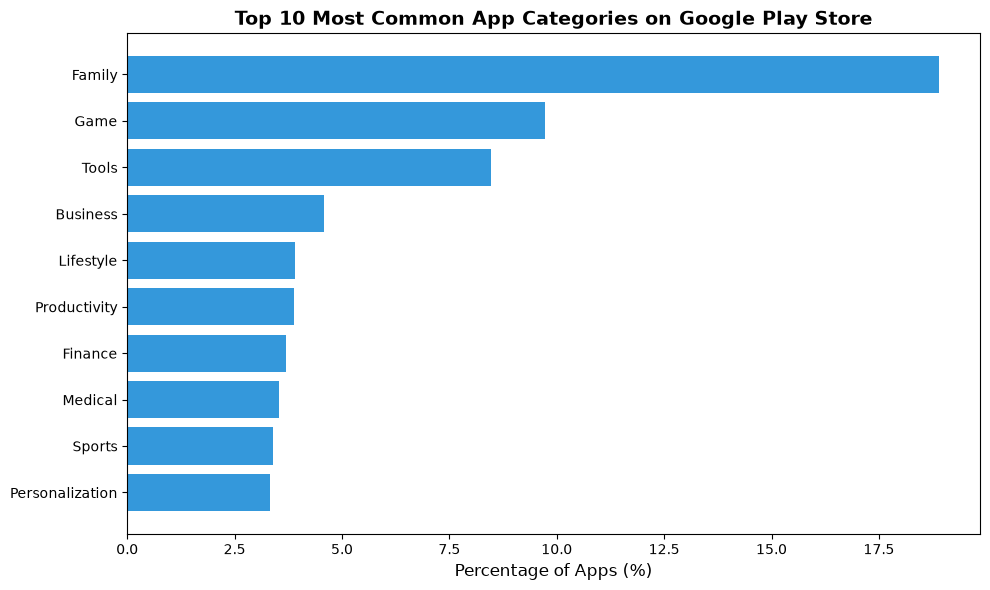

In [49]:
# Grab top 10 categories from Android data
cat_percentages = freq_table(android_final, 1)
sorted_cats = sorted(cat_percentages.items(), key=lambda x: x[1], reverse=True)[:10]

categories = [item[0].replace('_', ' ').title() for item in sorted_cats]
percentages = [item[1] for item in sorted_cats]

# Reverse for top-down display in bar chart
categories.reverse()
percentages.reverse()

plt.figure(figsize=(10, 6))
plt.barh(categories, percentages, color='#3498db')
plt.title('Top 10 Most Common App Categories on Google Play Store', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Apps (%)', fontsize=12)
plt.tight_layout()

# Save for GitHub README
plt.savefig('../visuals/top_android_categories.png', dpi=300)
plt.show()

2. Average Installs/Ratings by Category (Comparing Stores)

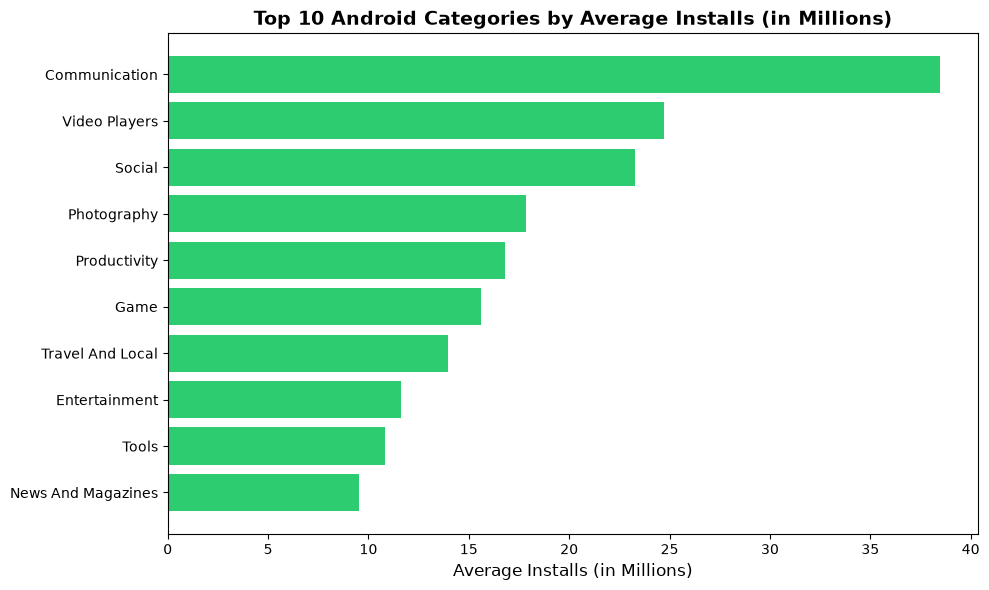

In [51]:
# Top 10 Android categories by Average Installs
android_pop_apps.sort(reverse=True)
top_android_pop = android_pop_apps[:10]

top_cats = [item[1].replace('_', ' ').title() for item in top_android_pop]
avg_installs = [item[0] / 1e6 for item in top_android_pop] # Convert to Millions

top_cats.reverse()
avg_installs.reverse()

plt.figure(figsize=(10, 6))
plt.barh(top_cats, avg_installs, color='#2ecc71')
plt.title('Top 10 Android Categories by Average Installs (in Millions)', fontsize=14, fontweight='bold')
plt.xlabel('Average Installs (in Millions)', fontsize=12)
plt.tight_layout()

plt.savefig('../visuals/android_popular_categories.png', dpi=300)
plt.show()

3. App Store vs. Google Play Market Composition (Pie Charts)

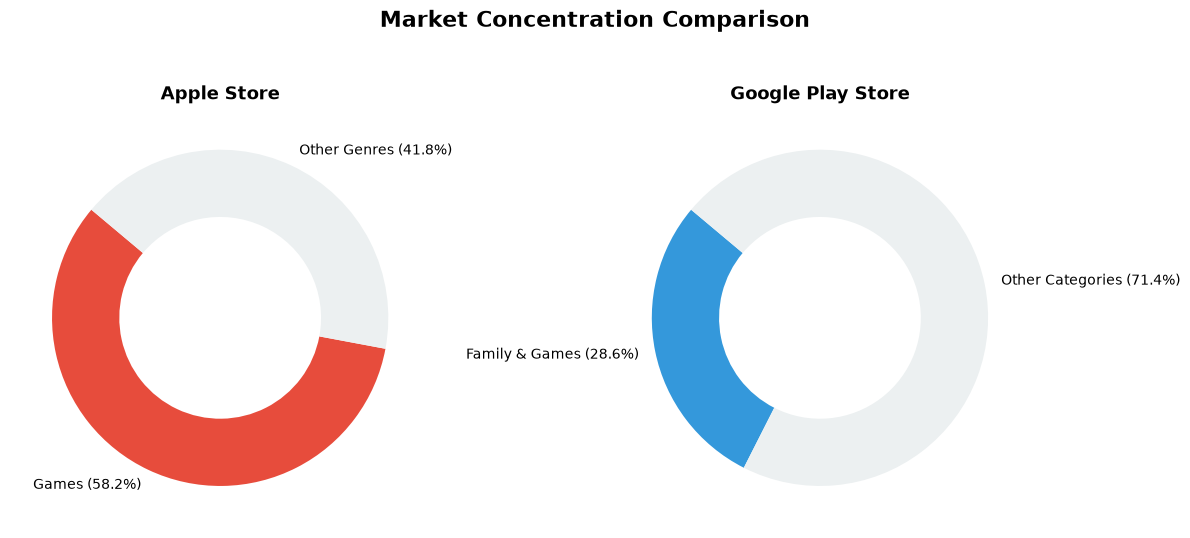

In [58]:
# Prepare iOS high-level split (Games vs Others)
ios_genres = freq_table(ios_final, -5)
games_pct = ios_genres.get('Games', 0)
ios_split = [games_pct, 100 - games_pct]
ios_labels = [f'Games ({games_pct:.1f}%)', f'Other Genres ({100 - games_pct:.1f}%)']

# Prepare Android high-level split (Games + Family vs Others)
android_cats = freq_table(android_final, 1)
family_pct = android_cats.get('FAMILY', 0)
game_pct = android_cats.get('GAME', 0)
android_split = [family_pct + game_pct, 100 - (family_pct + game_pct)]
android_labels = [f'Family & Games ({family_pct+game_pct:.1f}%)', f'Other Categories ({100-(family_pct+game_pct):.1f}%)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# iOS Donut
ax1.pie(ios_split, labels=ios_labels, colors=['#e74c3c', '#ecf0f1'], startangle=140, wedgeprops=dict(width=0.4))
ax1.set_title('Apple Store', fontsize=13, fontweight='bold')

# Android Donut
ax2.pie(android_split, labels=android_labels, colors=['#3498db', '#ecf0f1'], startangle=140, wedgeprops=dict(width=0.4))
ax2.set_title('Google Play Store', fontsize=13, fontweight='bold')

plt.suptitle('Market Concentration Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('../visuals/market_composition.png', dpi=300)
plt.show()

4. Install Buckets Distribution (Histogram)

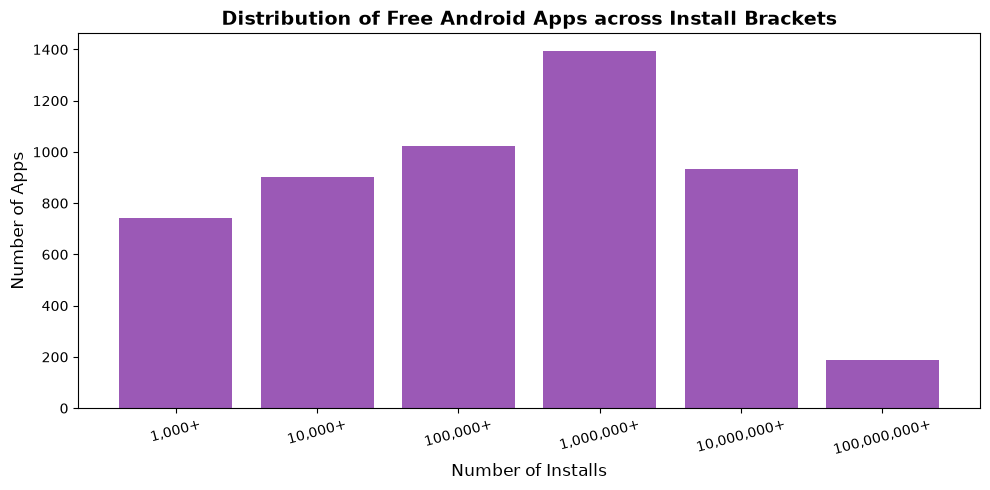

In [55]:
# Aggregate counts per install bucket using pure Python dictionaries
install_counts = {}
for app in android_final:
    installs = app[5]
    install_counts[installs] = install_counts.get(installs, 0) + 1

# Select key ordered tiers for plotting
ordered_tiers = ['1,000+', '10,000+', '100,000+', '1,000,000+', '10,000,000+', '100,000,000+']
counts = [install_counts.get(tier, 0) for tier in ordered_tiers]

plt.figure(figsize=(10, 5))
plt.bar(ordered_tiers, counts, color='#9b59b6')
plt.title('Distribution of Free Android Apps across Install Brackets', fontsize=14, fontweight='bold')
plt.xlabel('Number of Installs', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig('../visuals/install_distribution.png', dpi=300)
plt.show()

5. Visualizing the Impact of Outliers (Before vs. After Skewness Removal)

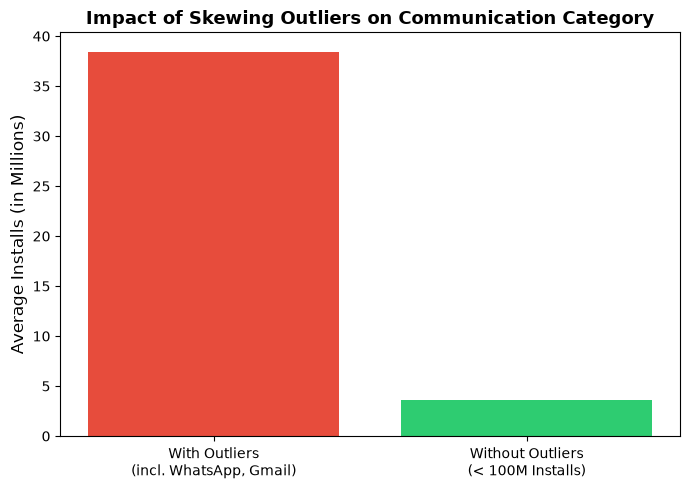

In [57]:
comm_with_outliers = 38456119.17
comm_without_outliers = 3603485.39  # From cell 41 in your notebook

plt.figure(figsize=(7, 5))
bars = plt.bar(['With Outliers\n(incl. WhatsApp, Gmail)', 'Without Outliers\n(< 100M Installs)'], 
               [comm_with_outliers / 1e6, comm_without_outliers / 1e6], 
               color=['#e74c3c', '#2ecc71'])

plt.ylabel('Average Installs (in Millions)', fontsize=12)
plt.title('Impact of Skewing Outliers on Communication Category', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/outlier_impact_communication.png', dpi=300)
plt.show()